In [17]:
# 引入模組
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

In [18]:
# 模組一：訊號＆雜訊產生（記得按照講義給的數據 不客氣）
# 取樣設定
fs = 10000          # sampling rate
T = 5               # total time (s)
t = np.linspace(0, T, fs*T) #生成時間向量

# 真實訊號
f_sig = 50        
omega = 2*np.pi*f_sig
A_sig = 10e-6 # 很小的訊號
signal = A_sig * np.sin(omega * t)

# 雜訊
noise_amp = 10e-3 #snr=10e-3
noise = noise_amp * np.random.randn(len(t))

# 實際量測
measured = signal + noise

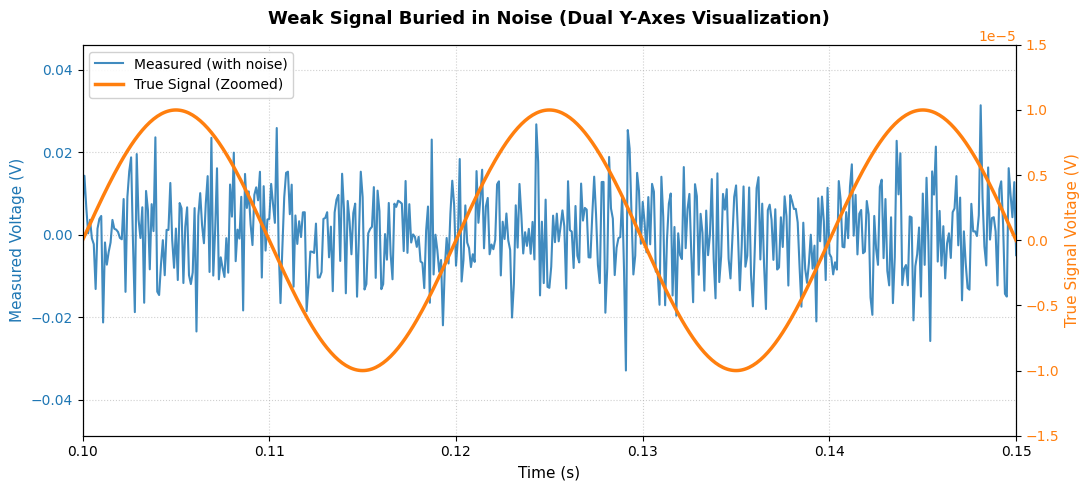

In [19]:
# 畫高級雙軸圖
fig, ax1 = plt.subplots(figsize=(11, 5))

# 左側 Y 軸（真實信號）
color1 = '#1f77b4'  # 經典藍色
ax1.set_xlabel('Time (s)', fontsize=11)
ax1.set_ylabel('Measured Voltage (V)', color=color1, fontsize=11)
line1 = ax1.plot(t, measured, color=color1, alpha=0.85, label='Measured (with noise)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle=':', alpha=0.6)

# 建立右側 Y 軸 (共用 X 軸)
ax2 = ax1.twinx()  

# 繪製右側 Y 軸：真實訊號 (True Signal，放大顯示)
color2 = '#ff7f0e'  # 經典橘色
ax2.set_ylabel('True Signal Voltage (V)', color=color2, fontsize=11)
line2 = ax2.plot(t, signal, color=color2, linewidth=2.5, label='True Signal (Zoomed)')
ax2.tick_params(axis='y', labelcolor=color2)

# 動態調整右側 y 軸範圍，讓正弦波震盪比例更優雅 (保留上下一些留白)
ax2.set_ylim(-A_sig * 1.5, A_sig * 1.5)

# 關鍵修正：將 X 軸範圍限制在最後 0.1 秒 (0.1s - 0.2s)
ax1.set_xlim(0.1, 0.15)

# --- 3. 合併左右兩側的圖例 (Legend) ---
# 因為是雙軸，若分開呼叫 legend() 會重疊，必須手動合併
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

# 設定標題
plt.title('Weak Signal Buried in Noise (Dual Y-Axes Visualization)', fontsize=13, fontweight='bold', pad=15)

# 優化排版並顯示
plt.tight_layout()
plt.show()

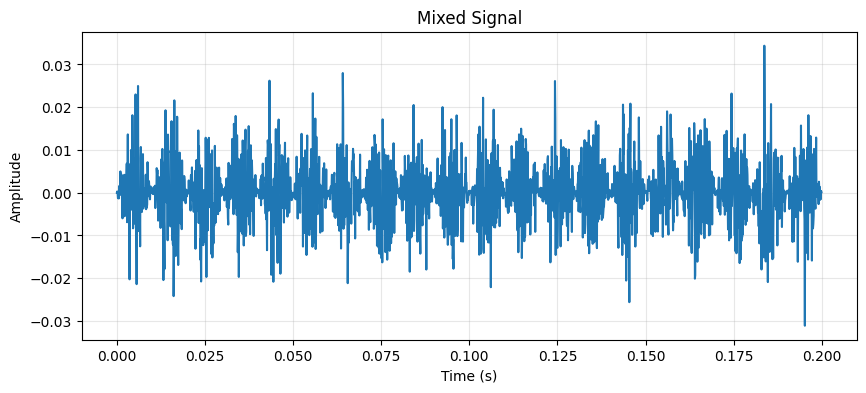

In [20]:
# 模組二：混頻
# reference signal
reference = np.sin(omega * t)

# mixing
mixed = measured * reference

# 畫畫畫畫畫圖
plt.figure(figsize=(10,4))
plt.plot(t[:2000], mixed[:2000])
plt.title('Mixed Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.show()
